# 32.6) PyCaret para Regressão

## Ambiente no Anaconda

In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/pycaret-env/bin/python


### Regressão temos o objetivo de prever um número


In [2]:

import numpy as np

# from pycaret.utils import enable_colab
# enable_colab()

##### Base de dados

In [3]:

from pycaret.datasets import get_data
# base de dados
todas_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [4]:
dataset = get_data('automobile')

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
list(dataset)

#make -tipo de carro
# 'fuel-type' combustível

# 'num-of-doors' número de portas
# 'body-style' estilo 


 # 'engine-type', tipo 
 # 'num-of-cylinders', número de cilindros

# por meio dos dados , prever o price

# ----------------------------------------------------------------
# problema no string, mas não precisamos fazer o pré processamento, no pycaret faz direto.


['symboling',
 'normalized-losses',
 'make',
 'fuel-type',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-type',
 'num-of-cylinders',
 'engine-size',
 'fuel-system',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price']

In [6]:
# automobile	Multivariate	Regression	price	NaN	202	26	Y

In [7]:
# características do veículo para prever o preço

In [8]:
type(dataset) # formato dataframe

pandas.core.frame.DataFrame

In [9]:
dataset.shape

(202, 26)

In [10]:
# base => dataset

# definindo a base de treinamento
# fraca com base de 90% dos dados,
#para o registro, random_state, gera sempre a mesma semente, 1, o resultado é sempre o mesmo, rodando várias vezes
base_treinamento = dataset.sample(frac=0.9, random_state =1)

base_treinamento.shape

(182, 26)

In [11]:

# valor de index para subtrair, e gerar a base de teste
base_treinamento.index



Index([196,  95, 173, 123,  38,  94,  78,  58,  29,   4,
       ...
        22,  61,  63,   7, 198, 141,  86,  96,  68,  50],
      dtype='int64', length=182)

In [12]:

base_teste = dataset.drop(base_treinamento.index)

In [13]:
base_teste.shape # registros restantes

(20, 26)

 ## Problema de regressão
 
 ### Configuração do ambiente PyCaret
 

In [14]:
# base para o treinamento e indicamos o alvo que queremos prever (atributo que queremos prever).
# session_id = 1, para termos sempre o mesmo resultado (mesma ideia do random_state =1)

# abaixo estão os dados sobre o experimento

# Rows with missing values	19.2% linha com dados faltantes;

In [15]:
 from pycaret.regression import setup
 
 experimento = setup(data = base_treinamento, target = 'price', session_id = 1)

,Description,Value
0,Session id,1
1,Target,price
2,Target type,Regression
3,Original data shape,"(182, 26)"
4,Transformed data shape,"(182, 89)"
5,Transformed train set shape,"(127, 89)"
6,Transformed test set shape,"(55, 89)"
7,Numeric features,11
8,Categorical features,14
9,Rows with missing values,19.2%


In [16]:
experimento

In [17]:
# Para ver essa tabela de novo a qualquer momento, use:
experimento.pull()

,Description,Value
0,Session id,1
1,Target,price
2,Target type,Regression
3,Original data shape,"(182, 26)"
4,Transformed data shape,"(182, 89)"
5,Transformed train set shape,"(127, 89)"
6,Transformed test set shape,"(55, 89)"
7,Numeric features,11
8,Categorical features,14
9,Rows with missing values,19.2%


In [18]:
# Ver quais colunas ele considerou numéricas
print("Numéricas:", experimento.get_config('X_train').select_dtypes(include=[np.number]).columns.tolist())

# Ver quais colunas ele considerou categóricas
print("Categóricas:", experimento.get_config('X_train').select_dtypes(exclude=[np.number]).columns.tolist())

Numéricas: ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg']
Categóricas: ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm']


In [19]:
#Numeric features	11, atributos ou colunas númericas

# Categorical features	14, atributos ou colunas categoricas, strings

## treinamento de vários modelos com validação cruzada

Machine Learning: Introdução a Validação Cruzada

https://www.youtube.com/watch?v=RczbeFs_WbQ

In [20]:

# validação cruzada, criando os modelos que melhor seria utilizados para trabalhar com os dadis
from pycaret.regression import compare_models

modelos  = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lasso,Lasso Regression,2246.0830,8981652.1742,2906.6047,0.8349,0.2232,0.1851,0.1110
ridge,Ridge Regression,2377.1909,10677746.3233,3131.7724,0.8243,0.2449,0.2003,0.0250
llar,Lasso Least Angle Regression,2374.4369,11770898.8149,3257.3446,0.8063,0.2438,0.2005,0.0260
et,Extra Trees Regressor,2335.9172,14202221.2140,3324.1280,0.8033,0.2112,0.1659,0.0360
gbr,Gradient Boosting Regressor,2319.2400,15320092.2210,3399.8289,0.7900,0.2249,0.1723,0.0300
lr,Linear Regression,2450.0982,11211308.7115,3192.2701,0.7841,0.2756,0.2079,0.2480
rf,Random Forest Regressor,2478.7238,16278446.1348,3550.4348,0.7690,0.2393,0.1856,0.0450
ada,AdaBoost Regressor,2679.8270,16372970.1570,3678.6879,0.7586,0.2556,0.2140,0.0320
lightgbm,Light Gradient Boosting Machine,2733.3761,17661793.5055,3934.4605,0.7227,0.2599,0.2001,15.8570
knn,K Neighbors Regressor,2720.2385,19960962.2899,3976.4590,0.7224,0.2553,0.1967,0.0240


Algorimos com os testes, e os melhores resultados

In [21]:

 #	        Model	             MAE	MSE	          RMSE	          R2	RMSLE	MAPE	TT (Sec)
#	Lasso Regression	2246.0830	8981652.1742	2906.6047	0.8349	0.2232	0.1851	0.2180

In [22]:
#                               RMSLE	MAPE
#et Extra Trees Regressor		0.2112	0.1659

#### Métricas conhecidas quando avaliamos os algoritmos da Regressão

Isso depois de fazer a validação cruzada que foi cortada por 10 pedaços, ou divido em 10 folds para cada algoritmo. 

In [23]:
# --- ANÁLISE COMPARATIVA DE RESULTADOS (REGRESSÃO) ---

# MAE (Mean Absolute Error): Erro médio absoluto em valor real. 
# Indica quanto o modelo erra, em média, no preço (ex: erra por +- R$ 500,00).

# MSE (Mean Squared Error) & RMSE (Root Mean Squared Error):
# Penalizam erros grandes. Se o RMSE estiver muito maior que o MAE, 
# o modelo está errando feio em alguns preços específicos (outliers).

# R2 (R-Squared): Coeficiente de Determinação. 
# Indica quanto da variação do preço o modelo explica. 1.0 é o ideal (100%).
# Se for 0.80, o modelo explica 80% do fenômeno dos preços.

# RMSLE (Root Mean Squared Logarithmic Error): 
# Útil quando o preço varia de valores muito pequenos a muito grandes. 
# Penaliza mais subestimar o preço do que superestimar.

# MAPE (Mean Absolute Percentage Error): Erro médio em porcentagem.
# Se o MAPE é 0.10, o modelo erra cerca de 10% do valor do produto.

# TT (Sec): Tempo de Treinamento. 
# Crucial para modelos em produção que precisam de re-treino constante.

# --- PERFORMANCE DOS MODELOS ---

# 1. Random Forest / LGBM: Geralmente dominam o R2 e RMSE por captarem relações 
# não-lineares complexas entre as características e o preço.

# 2. KNN: Pode ter um MAE baixo, mas sofre se não houver normalização, 
# pois distâncias entre preços altos e baixos variam drasticamente.

# 3. LDA/QDA: (Se usados como Regressores Logísticos em faixas de preço) 
# São mais rígidos e costumam ter métricas piores se o preço flutuar muito.

Olhe primeiro para o R2: É a forma mais rápida de ver quem "entendeu" melhor o nosso banco de dados.

Comparar MAE vs RMSE: Se o RMSE for muito maior, seu modelo está tendo dificuldades com preços muito fora do padrão (muito caros ou muito baratos).

Verificar o MAPE: Ele é o mais fácil de explicar para um cliente. "Nosso modelo erra o preço em apenas X%".

In [24]:
#experimento.plot_model('modelo?', plot='error')

1. Lasso Regression (Least Absolute Shrinkage and Selection Operator)

O Lasso é uma versão da Regressão Linear que tem um "superpoder": ele consegue zerar colunas que não servem para nada.


In [25]:
# Lasso Regression:
# Uma regressão linear que aplica penalidade (L1) aos coeficientes.
# Ponto forte: Seleção automática de variáveis. Se uma coluna não ajuda a prever o preço, 
# o Lasso reduz o peso dela a zero, simplificando o modelo.
# Ideal para: Quando temo muitas colunas e suspeita que poucas são realmente importantes.
# Sensibilidade: Precisa que os dados estejam na mesma escala (StandardScaler).

2. Extra Trees Regressor (Extremely Randomized Trees)
   
Ele é o "primo" mais radical do Random Forest. Enquanto o Random Forest procura o melhor corte para cada galho, o Extra Trees escolhe cortes de forma totalmente aleatória e depois seleciona o melhor entre esses aleatórios.

In [26]:
# Extra Trees Regressor:
# Similar ao Random Forest, mas com mais aleatoriedade na criação das divisões das árvores.
# Ponto forte: Reduz a variância e o risco de overfitting melhor que o Random Forest padrão.
# Velocidade: Costuma ser mais rápido que o Random Forest porque não precisa "calcular" o 
# melhor corte matematicamente, ele testa alguns aleatórios e escolhe o melhor.
# Ideal para: Dados com muito ruído onde o Random Forest está "decorando" demais os erros.

In [27]:
modelos


Lasso(random_state=1)

In [28]:
modelos.get_params() # do lasso

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': 1,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

Valer mais para considerar o R2, 


olhar também os modelos tradicionais Linear Regression (lr - Linear Regression), mas teve pouca performance no R2.

Fazer o tuning dos modelos, para escolher os melhores parâmetros, para aumentar o desempenho. 


Decision Tree Rgressor => Decision Tree Regressar, baseada em árvores de decisão (Decision Tree Regressor - dt)

Valor R2  = 0,7077, vamos tentar aumentar a performance e desempenho, fazendo o tuning dos parâmetros no modelo

### Tuning dos modelos

### escolhido o modelo para Decision Tree Regressor - dt

In [29]:
from pycaret.regression import create_model

dt = create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2350.4615,11474637.5385,3387.4234,0.5777,0.2862,0.2392
1,2920.0769,13155295.9231,3627.0230,0.7144,0.2317,0.2040
2,3143.0000,17396272.6923,4170.8839,0.6782,0.2898,0.2440
3,5327.3846,88496632.0000,9407.2649,0.3459,0.3910,0.2155
4,2373.4615,12664310.5385,3558.6951,0.8039,0.2340,0.1915
5,2813.0769,18067140.1538,4250.5459,0.8749,0.2312,0.1824
6,2078.0769,8640675.3077,2939.5026,0.8148,0.2219,0.1749
7,3326.7500,17757437.7500,4213.9575,0.7554,0.3247,0.2832
8,2123.3333,8495746.3333,2914.7464,0.7298,0.2653,0.1781


escolhido o modelo com a validação cruzada (com os 10 folds) e os dados da base da escolha.

In [30]:
dt

DecisionTreeRegressor(random_state=1)

In [31]:
dt.get_params() # parâmetros utilizados

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

A Decision Tree Regressor (Árvore de Decisão para Regressão) funciona criando uma série de perguntas "sim ou não" sobre os dados para chegar a um valor numérico final (como o preço). Diferente da classificação, aqui o resultado final em cada folha é a média dos valores dos dados que caíram ali.

In [32]:
# --- Decision Tree Regressor (Parâmetros) ---

# criterion='squared_error': Métrica para medir a qualidade do corte. 
# O 'erro quadrático' busca reduzir a variância dentro de cada nó (média das previsões).

# splitter='best': Escolhe a melhor divisão possível em cada nó. 
# Alternativa: 'random' (escolhe um corte aleatório, sendo mais rápido e evitando overfitting).

# max_depth=None: A árvore cresce até que todas as folhas sejam puras ou 
# contenham menos que 'min_samples_split'. Cuidado: sem limite causa Overfitting.

# min_samples_split=2: O número mínimo de amostras que um nó deve ter 
# para ser dividido em dois novos galhos.

# min_samples_leaf=1: O número mínimo de amostras que deve existir em 
# cada "folha" (final da árvore). Valores maiores suavizam o modelo.

# max_features=None: Considera todas as colunas (features) para decidir o melhor corte.

# random_state=1: Garante que a árvore seja construída da mesma forma em todas as rodadas.

# ccp_alpha=0.0: Parâmetro de "poda" (pruning). Valores maiores que 0 cortam 
# galhos que ajudam pouco, simplificando a árvore para melhorar a generalização.

# min_impurity_decrease=0.0: Um nó só é dividido se a redução do erro 
# for maior ou igual a este valor.

tuning faz vários testes com o modelo, utilzando parâmetros diferentes, com o objetivo de descobrimos qual é o melhor conjunto de parâmetros para esse algoritmo aplicado nessa base de dados (dt => Decision Tree Regressor ) 

### Tuning model

In [33]:
from pycaret.regression import tune_model

dt_tuning = tune_model(dt)



,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2398.7216,10364028.8675,3219.3212,0.6185,0.2332,0.2063
1,3816.9910,29676077.1953,5447.5754,0.3557,0.3083,0.2536
2,2738.6090,17072037.7634,4131.8323,0.6842,0.2722,0.2048
3,4996.5939,51443436.8378,7172.4080,0.6198,0.3009,0.2423
4,1988.6474,6672994.5845,2583.2140,0.8967,0.2074,0.1617
5,3359.3357,34673459.3491,5888.4174,0.7599,0.2170,0.1566
6,1636.9310,4999002.4521,2235.8449,0.8928,0.1526,0.1206
7,1716.5772,5345402.0592,2312.0126,0.9264,0.1560,0.1207
8,2056.4677,8648960.8395,2940.9116,0.7249,0.1907,0.1592


Fitting 10 folds for each of 10 candidates, totalling 100 fits


escolheu o mehor parâmetro, pelo dt_tuning, do Decision Tree Regressor, com uma média do R2 que aumentou 0.7368	

In [34]:
x = 0.7368*100/0.7077
print(f'o R2 pelo modelo teve um aumento de {x-100:.2f} %.')

o R2 pelo modelo teve um aumento de 4.11 %.


In [35]:
dt_tuning

DecisionTreeRegressor(criterion='friedman_mse', max_depth=13,
                      max_features='sqrt', min_impurity_decrease=0.0005,
                      min_samples_leaf=3, min_samples_split=7, random_state=1)

In [36]:
dt_tuning.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'max_depth': 13,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0005,
 'min_samples_leaf': 3,
 'min_samples_split': 7,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

### Gráficos

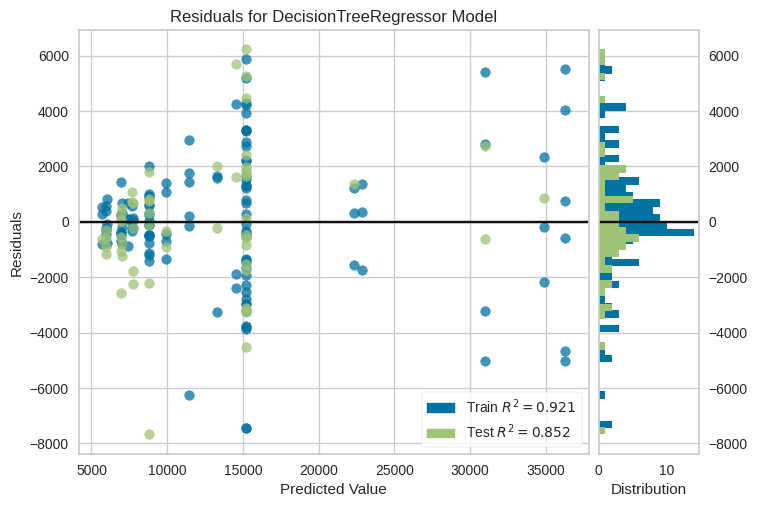

In [37]:

from pycaret.regression import plot_model

plot_model(dt_tuning)

problema de regressão, R2 com cálculo de treino e teste


resíduo e observar o quanto de dados está fora da linha do zero. 


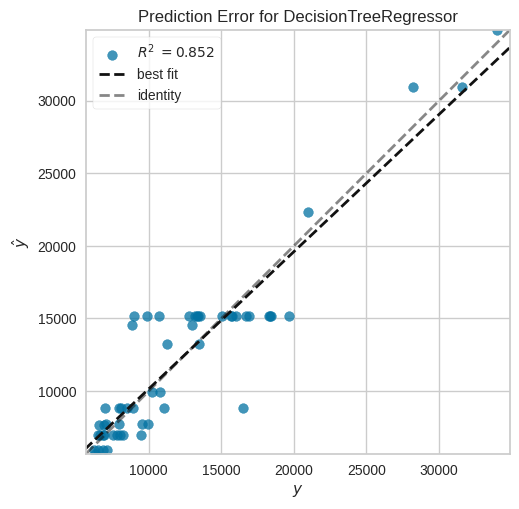

In [38]:
plot_model(dt_tuning, plot = 'error')

best fit => linha principal, para fazer a previsão dos dados

Ranking das características dos carros, mais importantes para prever os preços

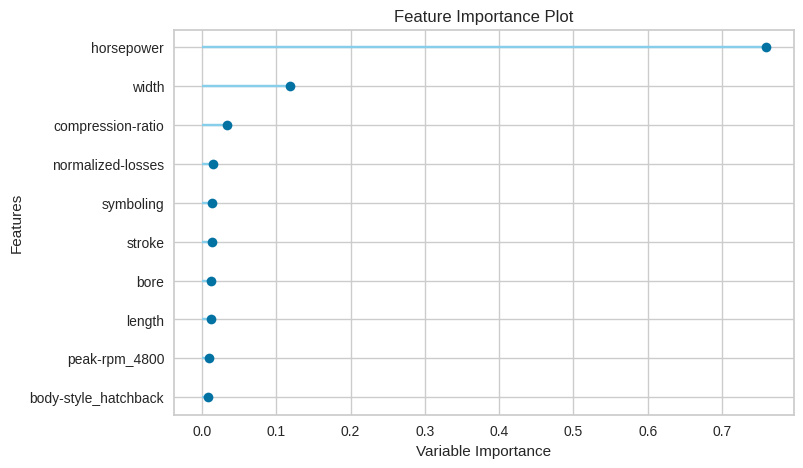

In [39]:
plot_model(dt_tuning, plot = 'feature') # ranking da importância das variáveis ou colunas (features)

width => largura do carro

In [40]:
# base original dos dados
print(dataset.tail())

     symboling  normalized-losses   make fuel-type aspiration num-of-doors  \
197         -1               95.0  volvo       gas      turbo         four   
198         -1               95.0  volvo       gas        std         four   
199         -1               95.0  volvo    diesel      turbo         four   
200         -1               95.0  volvo       gas      turbo         four   
201         -1               95.0  volvo       gas      turbo         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
197      sedan          rwd           front       109.1  ...          141   
198      sedan          rwd           front       109.1  ...          173   
199      sedan          rwd           front       109.1  ...          145   
200      sedan          rwd           front       109.1  ...          141   
201      sedan          rwd           front       109.1  ...          141   

     fuel-system  bore  stroke compression-ratio horsepower  peak-rp

In [41]:
# atributos numéricos, principais se indicam caso o carro seja caro ou não.

#horsepower potencia o veículo
#compression-ratio - taxa de compressão
#width - largura

print(dataset[['horsepower','width','compression-ratio']].tail())

    horsepower  width  compression-ratio
197        160   68.8                8.7
198        134   68.9                8.8
199        106   68.9               23.0
200        114   68.9                9.5
201        114   68.9                9.5


In [42]:
# executar o evaluate model
from pycaret.regression import evaluate_model
evaluate_model(dt_tuning)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

várias informações em uma janela só

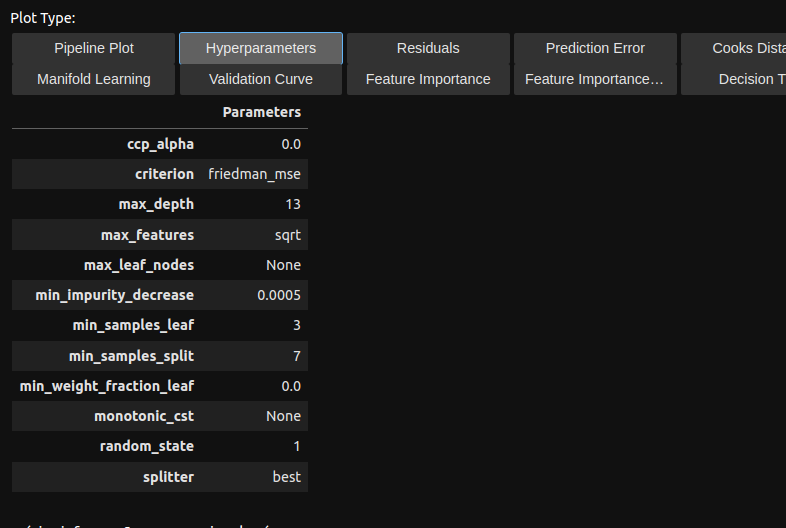

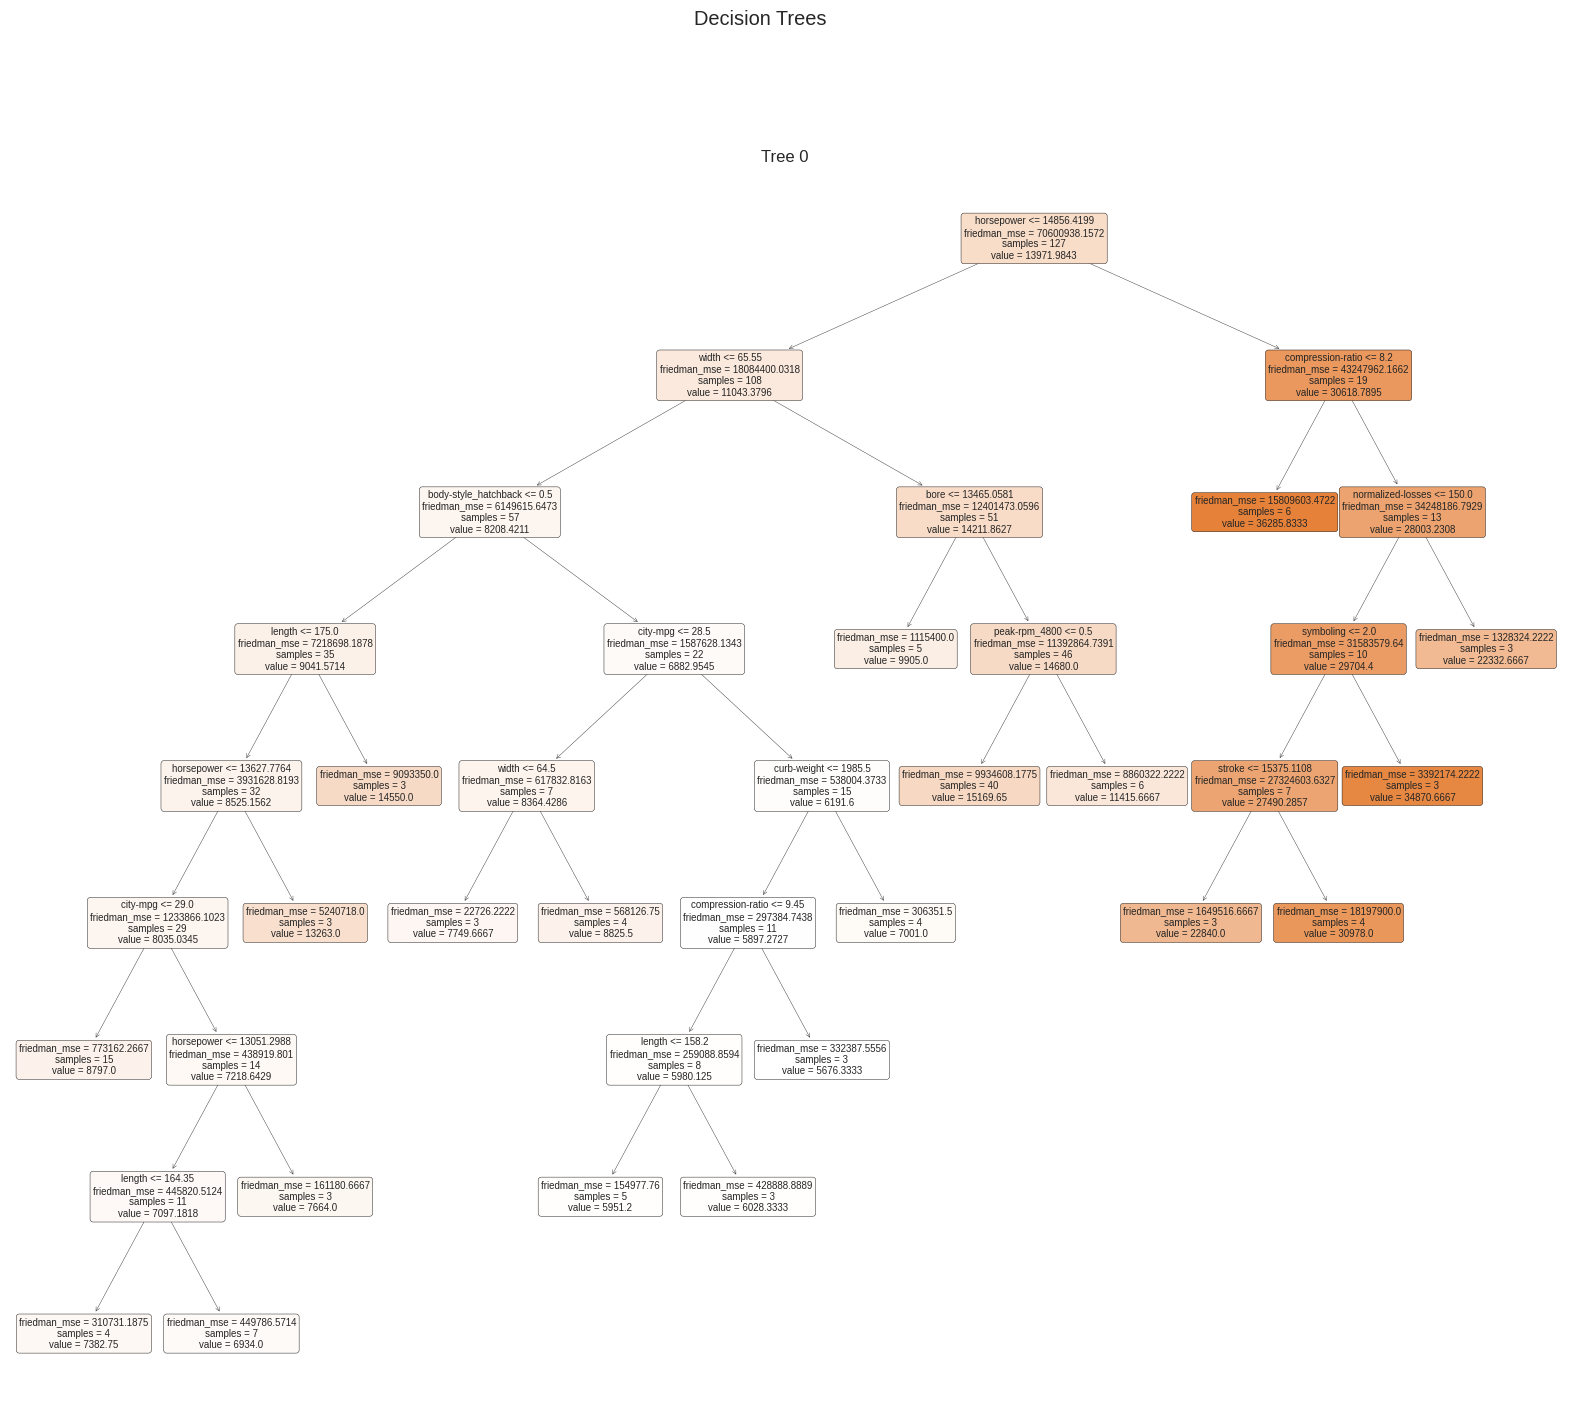

In [43]:
plot_model(dt_tuning, plot = 'tree') # ranking da importância das variáveis ou colunas (features)

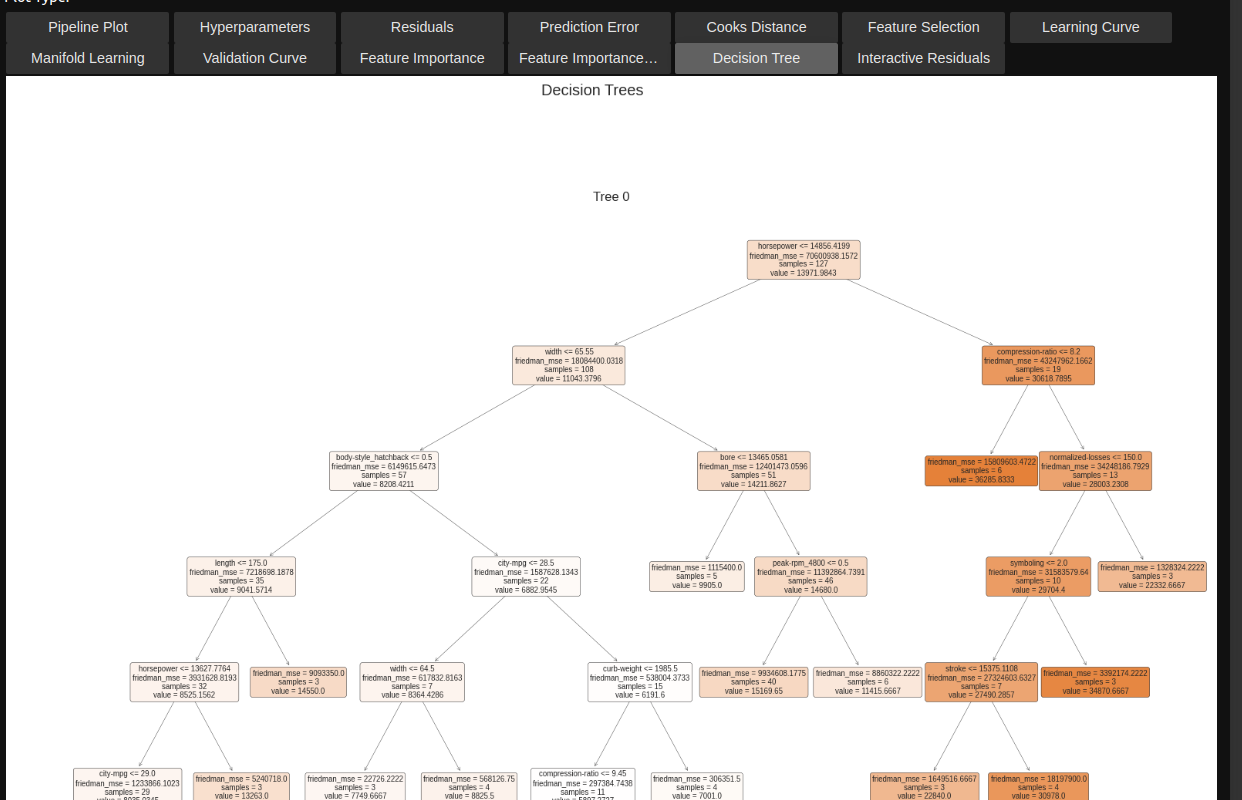

Verificando a árvore decisão para montar o preço do veículo.

## Previsões com o modelo 

In [45]:
from pycaret.regression import predict_model

predict_model(dt_tuning);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,1680.1794,5561123.1747,2358.2034,0.8523,0.1954,0.1474


Salvar o modelo em disco

In [46]:
from pycaret.regression import finalize_model

dt_final = finalize_model(dt_tuning)

print(dt_final)


Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['symboling', 'normalized-losses',
                                             'wheel-base', 'length', 'width',
                                             'height', 'curb-weight',
                                             'engine-size', 'compression-ratio',
                                             'city-mpg', 'highway-mpg'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['make', 'fuel-type', 'aspiration...
                                    transformer=TargetEncoder(cols=['bore',
                                                                    'stroke',
                                                                    'horsepower'],
                                                              handle_missing='return_nan'))),
                ('clean

In [47]:
dt_final.get_params()

{'memory': Memory(location=None),
 'steps': [('numerical_imputer',
   TransformerWrapper(include=['symboling', 'normalized-losses', 'wheel-base',
                               'length', 'width', 'height', 'curb-weight',
                               'engine-size', 'compression-ratio', 'city-mpg',
                               'highway-mpg'],
                      transformer=SimpleImputer())),
  ('categorical_imputer',
   TransformerWrapper(include=['make', 'fuel-type', 'aspiration', 'num-of-doors',
                               'body-style', 'drive-wheels', 'engine-location',
                               'engine-type', 'num-of-cylinders', 'fuel-system',
                               'bore', 'stroke', 'horsepower', 'peak-rpm'],
                      transformer=SimpleImputer(strategy='most_frequent'))),
  ('ordinal_encoding',
   TransformerWrapper(include=['fuel-type', 'aspiration', 'num-of-doors',
                               'engine-location'],
                      transfor

In [49]:
# DecisionTreeRegressor - Explicação dos Parâmetros:

   # DecisionTreeRegressor(criterion='friedman_mse', max_depth=13,
   #                                     max_features='sqrt',
   #                                     min_impurity_decrease=0.0005,
   #                                     min_samples_leaf=3, min_samples_split=7,
   #                                     random_state=1))])

# criterion='friedman_mse': Uma versão melhorada do Mean Squared Error (MSE). 
# Ele usa a correção de Friedman, que é mais estável e lida melhor com 
# aproximações em problemas de regressão complexos.

# max_depth=13: Limita a árvore a 13 níveis de "perguntas". 
# Ajuda a controlar o overfitting, impedindo que a árvore crie regras 
# específicas demais para cada pequena variação do preço.

# max_features='sqrt': Em cada corte (nó), a árvore sorteia a raiz quadrada 
# do número total de colunas para decidir o melhor galho. Isso aumenta a 
# diversidade e evita que uma única coluna domine toda a estrutura.

# min_impurity_decrease=0.0005: A árvore só cria um novo galho se houver 
# uma melhora mínima de 0.05% na redução do erro. Evita divisões inúteis.

# min_samples_split=7: Exige que um nó tenha pelo menos 7 amostras para 
# tentar uma nova divisão. Se tiver menos, ele vira uma folha (parada).

# min_samples_leaf=3: Cada folha final deve ter no mínimo 3 amostras. 
# Isso suaviza a previsão, evitando que o preço seja baseado em um único dado.

# random_state=1: Garante a reprodutibilidade dos resultados; 
# a árvore será construída sempre da mesma forma ao rodar o código.

Salva o arquivo dt_pycaret_regressao em .pkl

In [50]:
from pycaret.regression import save_model

save_model(dt_final,'dt_pycaret_regressao')


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['symboling', 'normalized-losses',
                                              'wheel-base', 'length', 'width',
                                              'height', 'curb-weight',
                                              'engine-size', 'compression-ratio',
                                              'city-mpg', 'highway-mpg'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['make', 'fuel-type', 'aspiration...
                                     transformer=TargetEncoder(cols=['bore',
                                                                     'stroke',
                                                                     'horsepower'],
                                                               handle_missing='return_nan'))),
         

pode usar em interface web também em .pkl

caso queiramos coletar o que foi salvo em .pkl

In [51]:
from  pycaret.regression import load_model

dt_carregado = load_model('dt_pycaret_regressao')

Transformation Pipeline and Model Successfully Loaded


In [52]:
dt_carregado

Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['symboling', 'normalized-losses',
                                             'wheel-base', 'length', 'width',
                                             'height', 'curb-weight',
                                             'engine-size', 'compression-ratio',
                                             'city-mpg', 'highway-mpg'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['make', 'fuel-type',...
                                    transformer=TargetEncoder(cols=['bore',
                                                                    'stroke',
                                                                    'horsepower'],
                                                              handle_missing='return_nan'))),
                ('clean_column_names',
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('actual_estimator',
                 DecisionTreeRegressor(criterion='friedman_mse', max_depth=13,
                                       max_features='sqrt',
                                       min_impurity_decrease=0.0005,
                                       min_samples_leaf=3, min_samples_split=7,
                                       random_state=1))])

In [53]:
dt_carregado.get_params()

{'memory': FastMemory(location=/tmp/joblib),
 'steps': [('numerical_imputer',
   TransformerWrapper(include=['symboling', 'normalized-losses', 'wheel-base',
                               'length', 'width', 'height', 'curb-weight',
                               'engine-size', 'compression-ratio', 'city-mpg',
                               'highway-mpg'],
                      transformer=SimpleImputer())),
  ('categorical_imputer',
   TransformerWrapper(include=['make', 'fuel-type', 'aspiration', 'num-of-doors',
                               'body-style', 'drive-wheels', 'engine-location',
                               'engine-type', 'num-of-cylinders', 'fuel-system',
                               'bore', 'stroke', 'horsepower', 'peak-rpm'],
                      transformer=SimpleImputer(strategy='most_frequent'))),
  ('ordinal_encoding',
   TransformerWrapper(include=['fuel-type', 'aspiration', 'num-of-doors',
                               'engine-location'],
                   

# pegar o modelo e fazer a previsão

In [54]:
previsoes = predict_model(dt_carregado, data = base_teste)

previsoes 

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,1436.1804,3896308.4047,1973.9069,0.9482,0.1611,0.1364


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,prediction_label
20,1,118.0,dodge,gas,std,two,hatchback,fwd,front,93.699997,...,2bbl,2.97,3.23,9.41,68,5500,37,41,5572,6854.333333
25,1,148.0,dodge,gas,std,four,sedan,fwd,front,93.699997,...,2bbl,2.97,3.23,9.40,68,5500,31,38,7609,7387.750000
37,0,106.0,honda,gas,std,two,hatchback,fwd,front,96.500000,...,1bbl,3.15,3.58,9.00,86,5800,27,33,9095,8336.111111
71,1,NaN,mercedes-benz,gas,std,two,hardtop,rwd,front,112.000000,...,mpfi,3.8,3.35,8.00,184,4500,14,16,45400,39718.333333
72,1,NaN,mercury,gas,turbo,two,hatchback,rwd,front,102.699997,...,mpfi,3.78,3.12,8.00,175,5000,19,24,16503,14314.666667
79,3,NaN,mitsubishi,gas,turbo,two,hatchback,fwd,front,95.900002,...,spdi,3.58,3.86,7.00,145,5000,19,24,12629,13569.500000
101,3,194.0,nissan,gas,std,two,hatchback,rwd,front,91.300003,...,mpfi,3.43,3.27,9.00,160,5200,19,25,17199,17015.666667
129,2,104.0,saab,gas,std,four,sedan,fwd,front,99.099998,...,mpfi,3.54,3.07,9.30,110,5250,21,28,12170,14989.800000
133,2,104.0,saab,gas,turbo,four,sedan,fwd,front,99.099998,...,mpfi,3.54,3.07,9.00,160,5500,19,26,18620,14989.800000
134,2,83.0,subaru,gas,std,two,hatchback,fwd,front,93.699997,...,2bbl,3.62,2.36,9.00,69,4900,31,36,5118,7847.000000


In [57]:
# id dos testes, com o real price, e o label ou prediction_label é a previsão

# comparativo de modo manual

In [69]:
# Agora o comparativo do erro médio absoluto desse algoritmo, errando 1436 dólares para cima ou para baixo


from sklearn.metrics import mean_absolute_error

mean_absolute_error(previsoes['price'], previsoes['prediction_label']) # subtação do erro absoluto

1436.180405982906

In [61]:
# MAE (Mean Absolute Error):
# Representa a média das diferenças absolutas entre o valor real e a previsão.
# Interpretável: O resultado está na mesma unidade do target (ex: Reais).
# Significado: Se o MAE é 50, o modelo erra, em média, R$ 50,00 para mais ou para menos.
# Diferença para o MSE: O MAE não penaliza erros grandes de forma agressiva; 
# ele trata todos os erros proporcionalmente (é mais "robusto" a outliers).

In [63]:
# ==============================================================================
# MÉTRICA: MAE (Mean Absolute Error)
# ------------------------------------------------------------------------------
# DEFINIÇÃO: Média da diferença absoluta entre os valores reais e as previsões.
# FÓRMULA: MAE = (1/n) * Σ |y_real - y_pred|
# INTERPRETAÇÃO: Se MAE = 500, o modelo erra em média R$ 500,00 por previsão.
# VANTAGEM: É fácil de explicar para pessoas não-técnicas e ignora o sinal do erro.
# ==============================================================================

In [71]:
# --- RESUMO DAS MÉTRICAS DE REGRESSÃO ---

# MSE (Mean Squared Error): Média dos erros ao quadrado. 
# Foco: Penaliza fortemente erros grandes (outliers).
# MSE   -> Soma((Real - Previsto)^2) / n



# RMSE (Root Mean Squared Error): Raiz do MSE. 
# Foco: Erro médio na mesma unidade do preço (mais sensível que o MAE).
# RMSE  -> Raiz_Quadrada(MSE)


# R2 (R-Squared): Coeficiente de determinação. 
# Foco: Percentual da variação dos dados explicada pelo modelo (Ideal próximo a 1.0).
# R2    -> 1 - (Soma_Erros_Quadrados / Soma_Variacao_Total)


# RMSLE (Root Mean Squared Logarithmic Error): Erro logarítmico. 
# Foco: Útil quando o preço tem grandes variações; penaliza erro de proporção.
# RMSLE -> Raiz_Quadrada( Média( (log(Previsto + 1) - log(Real + 1))^2 ) )


# MAPE (Mean Absolute Percentage Error): Erro percentual médio. 
# Foco: Interpretabilidade fácil (ex: "o modelo erra em média 5% do valor").
# MAPE  -> Média( |(Real - Previsto) / Real| ) * 100